In [2]:
# dgd_trainer_eqx.py
from __future__ import annotations
from typing import List, Tuple, Dict, Optional, Callable, Any
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx

# You already have these in your library:
from quantbayes.stochax.trainer.train import binary_loss, eval_step, predict

Array = jnp.ndarray
PRNG = jax.Array


def laplacian_from_edges(n_nodes: int, edges: List[Tuple[int, int]]) -> Array:
    """Undirected graph Laplacian L = D - A (nodes indexed 0..n-1)."""
    A = np.zeros((n_nodes, n_nodes), dtype=np.float32)
    for i, j in edges:
        if i == j:
            continue
        A[i, j] = 1.0
        A[j, i] = 1.0
    D = np.diag(A.sum(axis=1))
    L = D - A
    return jnp.array(L)


def mixing_matrix(n_nodes: int, edges: List[Tuple[int, int]], alpha: float) -> Array:
    """W = I - alpha * L, used for gossip step. Pick alpha < 1/deg_max."""
    L = laplacian_from_edges(n_nodes, edges)
    I = jnp.eye(n_nodes, dtype=jnp.float32)
    return I - alpha * L


def safe_alpha(edges: List[Tuple[int, int]], n_nodes: int) -> float:
    """Conservative alpha < 1/deg_max."""
    deg = np.zeros(n_nodes, dtype=np.int32)
    for i, j in edges:
        if i != j:
            deg[i] += 1
            deg[j] += 1
    deg_max = int(deg.max()) if n_nodes > 0 else 1
    return 0.49 / max(1, deg_max)


def _partition_params(model: eqx.Module):
    """Split model into (params, static) trees."""
    params, static = eqx.partition(model, eqx.is_inexact_array)
    return params, static


def _combine_params(params: Any, static: Any) -> eqx.Module:
    """Recombine (params, static) into a model."""
    return eqx.combine(params, static)


def _flatten_params_l2(pytree: Any) -> Array:
    """Flatten params pytree to a single 1D vector for consensus metrics."""
    leaves = jax.tree_util.tree_leaves(pytree)
    flat = [jnp.ravel(x) for x in leaves if x is not None]
    return jnp.concatenate(flat) if len(flat) > 0 else jnp.zeros((1,), dtype=jnp.float32)


def _tree_weighted_sum(weights: Array, param_list: List[Any]) -> Any:
    """
    Given weights w (n_nodes,) and param_list (length n_nodes), return sum_i w_i * params_i
    """
    def combine(*leaves):
        # leaves is a tuple (leaf_0, leaf_1, ..., leaf_{n-1})
        stacked = jnp.stack(leaves, axis=0)                  # (n_nodes, ...)
        return jnp.tensordot(weights, stacked, axes=(0, 0))  # (...)
    return jax.tree_util.tree_map(combine, *param_list)


def _tree_mix(W: Array, param_list: List[Any]) -> List[Any]:
    """
    Apply mixing params' -> W * params (per leaf, linear in node dimension).
    param_list: list of length n_nodes.
    """
    n = len(param_list)
    mixed: List[Any] = []
    for i in range(n):
        mixed_i = _tree_weighted_sum(W[i], param_list)
        mixed.append(mixed_i)
    return mixed


class DGDTrainerEqx:
    """
    Peer-to-peer DGD (exact algorithm in assignment):
      θ_{t+1/2} = (I - α L) θ_t
      θ_{t+1}^i  = θ_{t+1/2}^i - γ ∇L_i(θ_{t+1/2}^i)

    Uses your Equinox model + binary_loss for local objectives.
    """

    def __init__(
        self,
        model_init_fn: Callable[[PRNG], eqx.Module],
        n_nodes: int,
        edges: List[Tuple[int, int]],
        lam: float,
        alpha: float,
        gamma: float,
        T: int,
        loss_fn: Callable,                 # e.g., your binary_loss
        key: Optional[PRNG] = None,
    ):
        self.model_init_fn = model_init_fn
        self.n_nodes = n_nodes
        self.edges = edges
        self.lam = float(lam)
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.T = int(T)
        self.loss_fn = loss_fn
        self.key = key if key is not None else jr.PRNGKey(0)

        # Mixing matrix (gossip)
        self.W = mixing_matrix(n_nodes, edges, self.alpha)

        # Filled by `fit(...)`
        self.models: List[eqx.Module] = []
        self.states: List[Any] = []

    def _init_models(self) -> None:
        """Initialize one model per node."""
        models, states = [], []
        k = self.key
        for _ in range(self.n_nodes):
            k, sub = jr.split(k)
            m, s = eqx.nn.make_with_state(self.model_init_fn)(sub)
            models.append(m)
            states.append(s)
        self.key = k
        self.models = models
        self.states = states

    def _local_fullbatch_grad(
        self, model: eqx.Module, state: Any, X: Array, y: Array, key: PRNG
    ):
        """
        Compute gradient of local objective (average logistic + L2 on weights).
        Your binary_loss has signature (model, state, xb, yb, key)->(loss, new_state).
        We add L2 on all trainable leaves except biases if you wish; here we add on all leaves
        for simplicity. If you want to skip biases, filter by leaf name in your model.
        """

        def loss_with_l2(m: eqx.Module, s: Any, xb: Array, yb: Array, k: PRNG):
            base, new_s = self.loss_fn(m, s, xb, yb, k)  # average CE over xb
            # L2 penalty on trainable leaves
            p = eqx.filter(m, eqx.is_inexact_array)
            l2 = 0.5 * self.lam * sum([jnp.sum(jnp.square(leaf)) for leaf in jax.tree_util.tree_leaves(p)])
            return base + l2, new_s

        # Value+grad; we only use grad; keep state unchanged by using old state (loss_fn returns new state)
        (loss_val, _), grad = eqx.filter_value_and_grad(loss_with_l2, has_aux=True)(model, state, X, y, key)
        return loss_val, grad

    def _consensus_distance(self, params_list: List[Any]) -> float:
        """(1/n) sum_i ||θ_i - θ̄||^2 using flattened params."""
        vecs = [ _flatten_params_l2(p) for p in params_list ]
        stack = jnp.stack(vecs, axis=0)                                # (n, P)
        mean = jnp.mean(stack, axis=0, keepdims=True)                  # (1, P)
        sq = jnp.sum((stack - mean) ** 2, axis=1)                      # (n,)
        return float(jnp.mean(sq))

    def fit(
        self,
        parts: List[Tuple[Array, Array]],      # [(X_i, y_i)] for i=0..n-1  (labels in {0,1})
        X_full: Array,
        y_full: Array,
        eval_key: Optional[PRNG] = None,
    ) -> Dict[str, List[float]]:
        """
        Run DGD for T iterations.
        Returns dict with histories: 'loss_node1', 'consensus_sq'.
        """
        if not self.models:
            self._init_models()

        # Split models into (params, static) so we can mix params only
        params_list = []
        static_list = []
        for m in self.models:
            p, s = _partition_params(m)
            params_list.append(p); static_list.append(s)

        hist_loss_node1: List[float] = []
        hist_consensus: List[float] = []

        k = self.key if eval_key is None else eval_key

        for t in range(self.T):
            # ----- Phase 1: Gossip (mix) -----
            params_half = _tree_mix(self.W, params_list)  # list of params after mixing

            # Convert to models for local gradients
            models_half = [ _combine_params(ph, s) for ph, s in zip(params_half, static_list) ]

            # ----- Phase 2: Local gradient descent (full batch per node) -----
            grads = []
            for i in range(self.n_nodes):
                Xi, yi = parts[i]
                k, sub = jr.split(k)
                _, gi = self._local_fullbatch_grad(models_half[i], self.states[i], Xi, yi, sub)
                grads.append(gi)

            # GD step on params
            params_list = [ jax.tree_util.tree_map(lambda p, g: p - self.gamma * g, ph, gi)
                            for ph, gi in zip(params_half, grads) ]

            # ----- Logging -----
            # Build node 0 model (node index 0) after the step
            model_node1 = _combine_params(params_list[0], static_list[0])

            # Global training loss for node 1 (evaluate on full training data)
            # Using your eval_step; it expects (model, state, X, y, key, loss_fn)
            loss_node1 = float(eval_step(model_node1, self.states[0], X_full, y_full, k, self.loss_fn))
            hist_loss_node1.append(loss_node1)

            # Consensus squared distance
            hist_consensus.append(self._consensus_distance(params_list))

        # Keep final models
        self.models = [ _combine_params(p, s) for p, s in zip(params_list, static_list) ]
        self.key = k
        return {"loss_node1": hist_loss_node1, "consensus_sq": hist_consensus}


# ---------- centralized GD baseline (same model class) ----------

def centralized_gd_eqx(
    model_init_fn: Callable[[PRNG], eqx.Module],
    X: Array, y: Array,
    lam: float, gamma: float, T: int,
    loss_fn: Callable,
    key: Optional[PRNG] = None,
) -> Tuple[eqx.Module, List[float]]:
    """
    Full-batch GD on a single Equinox model using the same binary_loss (+L2) and step size.
    """
    k = jr.PRNGKey(0) if key is None else key
    model, state = eqx.nn.make_with_state(model_init_fn)(k)

    def loss_with_l2(m: eqx.Module, s: Any, xb: Array, yb: Array, k: PRNG):
        base, new_s = loss_fn(m, s, xb, yb, k)
        p = eqx.filter(m, eqx.is_inexact_array)
        l2 = 0.5 * lam * sum([jnp.sum(jnp.square(leaf)) for leaf in jax.tree_util.tree_leaves(p)])
        return base + l2, new_s

    losses: List[float] = []
    for _ in range(T):
        (loss_val, _), grads = eqx.filter_value_and_grad(loss_with_l2, has_aux=True)(model, state, X, y, k)
        losses.append(float(loss_val))
        params, static = _partition_params(model)
        new_params = jax.tree_util.tree_map(lambda p, g: p - gamma * g, params, grads)
        model = _combine_params(new_params, static)
    return model, losses


/Users/josephmargaryan/Desktop/quantbayes/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:2025-09-25 10:22:19,953:jax._src.xla_bridge:925: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-09-25 10:22:19,957:jax._src.xla_bridge:925: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:jax._src.xla_bridge:Unable to init

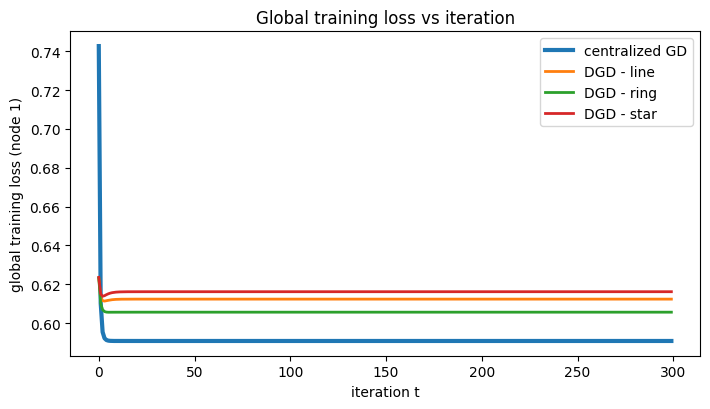

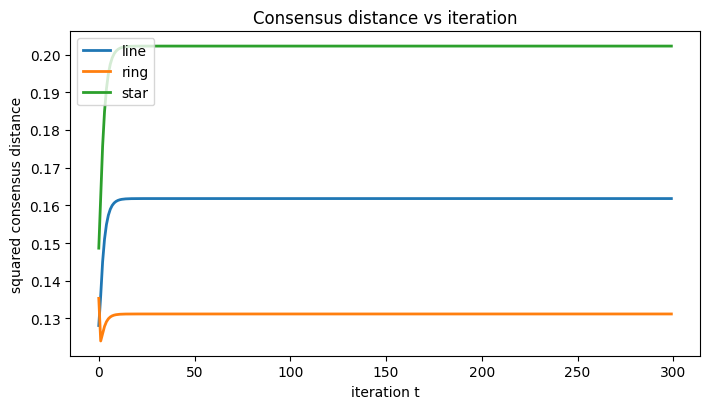

In [4]:
if __name__ == "__main__":
    import numpy as np
    import jax
    import jax.numpy as jnp
    import jax.random as jr
    import equinox as eqx
    import matplotlib.pyplot as plt

    # If you placed the trainer in a module, uncomment this import:
    # from dgd_trainer_eqx import DGDTrainerEqx, centralized_gd_eqx, safe_alpha
    from quantbayes.stochax.trainer.train import binary_loss, eval_step

    # ------------------------------
    # 1) Synthetic binary dataset
    # ------------------------------
    rng = np.random.RandomState(0)
    n_total, d = 4000, 50
    X = rng.randn(n_total, d).astype(np.float32)
    w_true = (rng.randn(d) / np.sqrt(d)).astype(np.float32)
    logits = X @ w_true
    p = 1.0 / (1.0 + np.exp(-logits))
    y = (rng.rand(n_total) < p).astype(np.float32)

    # Shuffle + split 80/20
    idx = rng.permutation(n_total)
    X, y = X[idx], y[idx]
    n_train = int(0.8 * n_total)
    X_tr_np, X_te_np = X[:n_train], X[n_train:]
    y_tr_np, y_te_np = y[:n_train], y[n_train:]

    # Standardize using train stats
    mu = X_tr_np.mean(axis=0, keepdims=True)
    sd = X_tr_np.std(axis=0, keepdims=True) + 1e-8
    X_tr_np = (X_tr_np - mu) / sd
    X_te_np = (X_te_np - mu) / sd

    X_tr = jnp.array(X_tr_np)
    y_tr = jnp.array(y_tr_np)
    X_te = jnp.array(X_te_np)
    y_te = jnp.array(y_te_np)

    # ------------------------------
    # 2) Simple Equinox logistic model
    # ------------------------------
    class LR(eqx.Module):
        lin: eqx.nn.Linear
        def __init__(self, key):
            self.lin = eqx.nn.Linear(d, 1, key=key)  # bias=True by default
        def __call__(self, x, key=None, state=None):
            return self.lin(x), state  # (logits, state)

    def model_init_fn(key: jax.Array) -> eqx.Module:
        return LR(key)

    # ------------------------------
    # 3) Uniform partition across 4 nodes
    # ------------------------------
    def uniform_partition(X: jnp.ndarray, y: jnp.ndarray, n_nodes: int):
        N = X.shape[0]
        base, rem = divmod(N, n_nodes)
        parts = []
        start = 0
        for i in range(n_nodes):
            size = base + (1 if i < rem else 0)
            parts.append((X[start:start+size], y[start:start+size]))
            start += size
        return parts

    parts = uniform_partition(X_tr, y_tr, 4)

    # ------------------------------
    # 4) Topologies + hyperparameters
    # ------------------------------
    edges_line = [(0, 1), (1, 2), (2, 3)]
    edges_ring = [(0, 1), (1, 2), (2, 3), (3, 0)]
    edges_star = [(3, 0), (3, 1), (3, 2)]

    lam = 1e-3
    alpha_line = safe_alpha(edges_line, 4)
    alpha_ring = safe_alpha(edges_ring, 4)
    alpha_star = safe_alpha(edges_star, 4)

    # Rough gamma from smoothness: L_smooth ≈ 0.25 * λ_max(X^T X / n) + lam
    def estimate_gamma(X: jnp.ndarray, lam: float) -> float:
        n = X.shape[0]
        XtX = (X.T @ X) / n
        v = jnp.ones((XtX.shape[0],), dtype=X.dtype)
        for _ in range(25):
            v = XtX @ v
            v = v / (jnp.linalg.norm(v) + 1e-12)
        lam_max = float(v @ (XtX @ v))
        L_smooth = 0.25 * lam_max + lam
        return 0.9 / L_smooth

    gamma = float(estimate_gamma(X_tr, lam))
    T = 300

    # ------------------------------
    # 5) Train DGD per topology (node 1 = index 0) + centralized baseline
    # ------------------------------
    trainer_line = DGDTrainerEqx(model_init_fn, 4, edges_line, lam, alpha_line, gamma, T, binary_loss, jr.PRNGKey(0))
    trainer_ring = DGDTrainerEqx(model_init_fn, 4, edges_ring, lam, alpha_ring, gamma, T, binary_loss, jr.PRNGKey(1))
    trainer_star = DGDTrainerEqx(model_init_fn, 4, edges_star, lam, alpha_star, gamma, T, binary_loss, jr.PRNGKey(2))

    hist_line = trainer_line.fit(parts, X_tr, y_tr, eval_key=jr.PRNGKey(10))
    hist_ring = trainer_ring.fit(parts, X_tr, y_tr, eval_key=jr.PRNGKey(11))
    hist_star = trainer_star.fit(parts, X_tr, y_tr, eval_key=jr.PRNGKey(12))

    _, loss_cgd = centralized_gd_eqx(model_init_fn, X_tr, y_tr, lam, gamma, T, binary_loss, jr.PRNGKey(123))

    # ------------------------------
    # 6) Plots
    # ------------------------------
    plt.figure(figsize=(7.2, 4.2))
    plt.plot(loss_cgd, label="centralized GD", linewidth=3)
    plt.plot(hist_line["loss_node1"], label="DGD - line", linewidth=2)
    plt.plot(hist_ring["loss_node1"], label="DGD - ring", linewidth=2)
    plt.plot(hist_star["loss_node1"], label="DGD - star", linewidth=2)
    plt.xlabel("iteration t")
    plt.ylabel("global training loss (node 1)")
    plt.title("Global training loss vs iteration")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7.2, 4.2))
    plt.plot(hist_line["consensus_sq"], label="line", linewidth=2)
    plt.plot(hist_ring["consensus_sq"], label="ring", linewidth=2)
    plt.plot(hist_star["consensus_sq"], label="star", linewidth=2)
    plt.xlabel("iteration t")
    plt.ylabel("squared consensus distance")
    plt.title("Consensus distance vs iteration")
    plt.legend()
    plt.tight_layout()
    plt.show()
